In [3]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (accuracy_score,classification_report,confusion_matrix,ConfusionMatrixDisplay,silhouette_score)

import warnings
warnings.filterwarnings("ignore")

In [4]:
df=pd.read_csv('/content/Country-data.csv')

print(df.head())
print(df.info())
print(df.columns)


               country  child_mort  exports  health  imports  income  \
0          Afghanistan        90.2     10.0    7.58     44.9    1610   
1              Albania        16.6     28.0    6.55     48.6    9930   
2              Algeria        27.3     38.4    4.17     31.4   12900   
3               Angola       119.0     62.3    2.85     42.9    5900   
4  Antigua and Barbuda        10.3     45.5    6.03     58.9   19100   

   inflation  life_expec  total_fer   gdpp  
0       9.44        56.2       5.82    553  
1       4.49        76.3       1.65   4090  
2      16.10        76.5       2.89   4460  
3      22.40        60.1       6.16   3530  
4       1.44        76.8       2.13  12200  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-nul

In [5]:
df.shape

(167, 10)

In [6]:
print(df.isnull().sum())

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [9]:
df.dtypes

,0
country,object
child_mort,float64
exports,float64
health,float64
imports,float64
income,int64
inflation,float64
life_expec,float64
total_fer,float64
gdpp,int64


In [10]:
#Creating Target Variable
median= df["income"].median()

df["Need_Aid"] = np.where(df["income"] < median,1,0)

df["Need_Aid"].value_counts()

,count
Need_Aid,
0,84
1,83


In [11]:
#Feature Selection
X = df.drop(["country", "Need_Aid"],axis=1)

y = df["Need_Aid"]

In [12]:
#Feature Scaling

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [13]:
#Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(X_scaled,y,test_size=0.2,random_state=42,stratify=y)

print(X_train.shape)
print(X_test.shape)

(133, 9)
(34, 9)


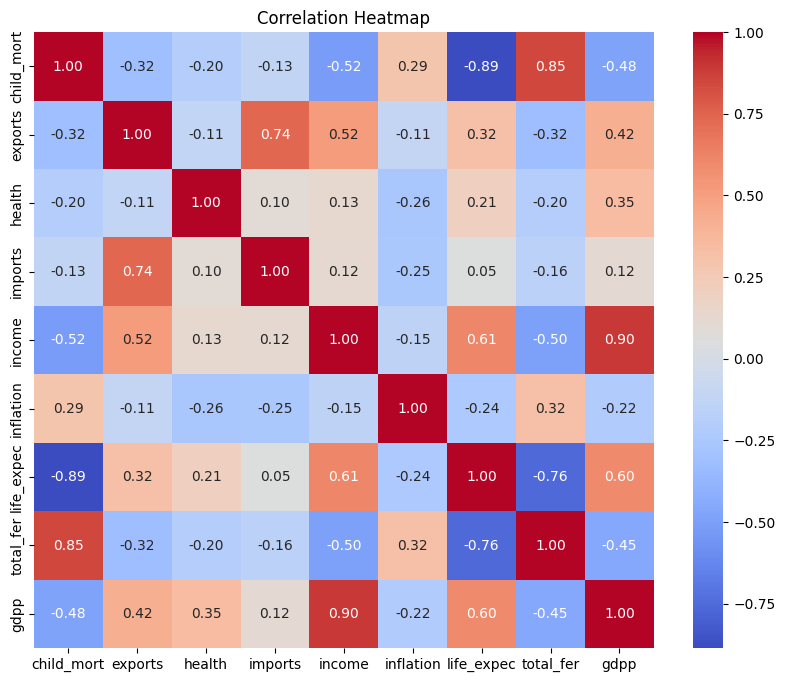

In [14]:
#Correlation Heatmap

plt.figure(figsize=(10,8))

sns.heatmap(
    df.drop("Need_Aid", axis=1).corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

The heatmap shows the relationship between different socio-economic factors. Income and GDP have a strong positive correlation, while child mortality has a negative correlation with life expectancy and income.

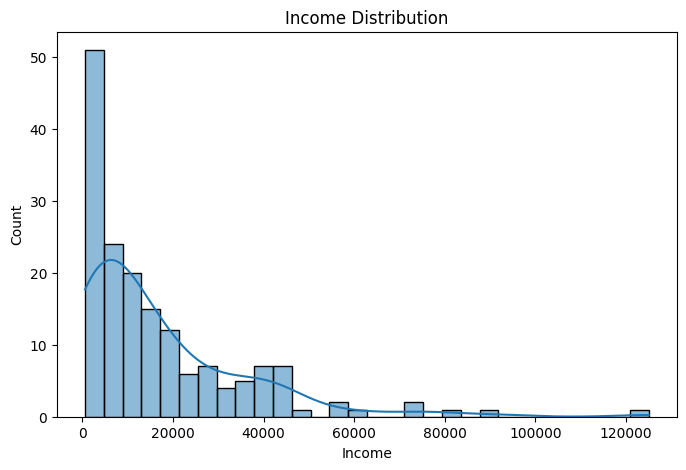

In [15]:
#Distribution of Income

plt.figure(figsize=(8,5))
sns.histplot(df["income"],bins=30,kde=True)

plt.title("Income Distribution")
plt.xlabel("Income")
plt.ylabel("Count")

plt.show()

Most countries have relatively low income, while only a few countries have very high income.

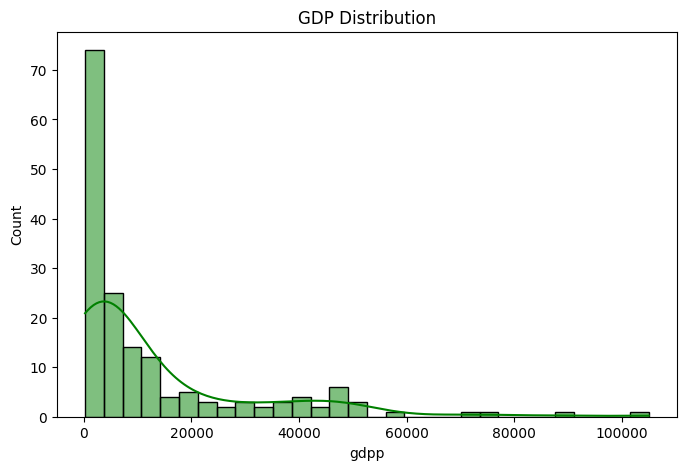

In [16]:
#GDP Distribution

plt.figure(figsize=(8,5))

sns.histplot(df["gdpp"],bins=30,kde=True,color="green")

plt.title("GDP Distribution")
plt.show()

The GDP distribution is positively skewed, indicating that only a small number of countries have very high GDP.

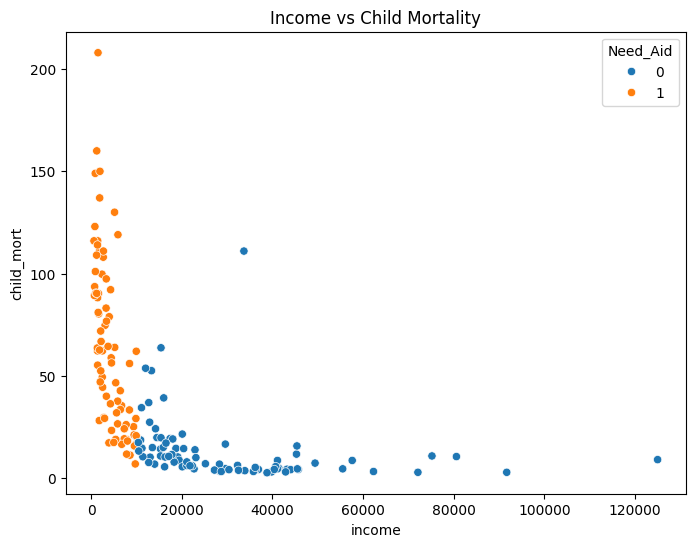

In [17]:
#Child Mortality vs Income

plt.figure(figsize=(8,6))

sns.scatterplot(data=df,x="income",y="child_mort",hue="Need_Aid")

plt.title("Income vs Child Mortality")

plt.show()

Countries with lower income generally have higher child mortality rates.

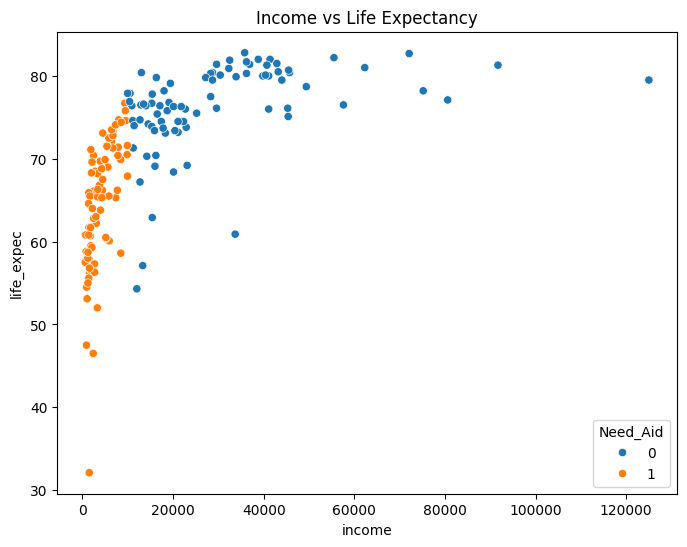

In [18]:
#Life Expectancy vs Income

plt.figure(figsize=(8,6))

sns.scatterplot(data=df,x="income",y="life_expec",hue="Need_Aid")

plt.title("Income vs Life Expectancy")

plt.show()

Higher-income countries generally have higher life expectancy.

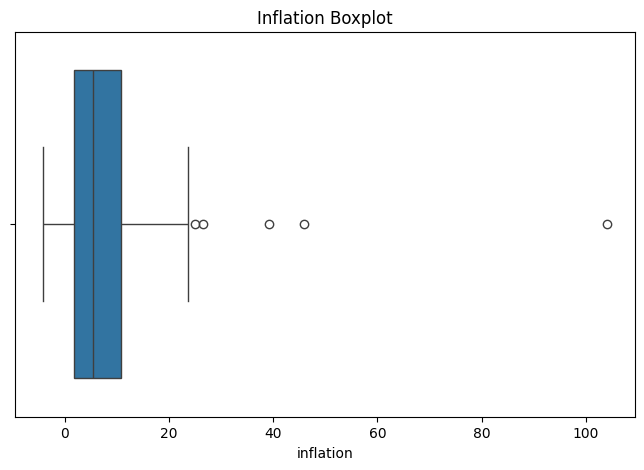

In [19]:
#Inflation Distribution

plt.figure(figsize=(8,5))

sns.boxplot(x=df["inflation"])

plt.title("Inflation Boxplot")

plt.show()

A few countries have extremely high inflation, which appear as outliers.

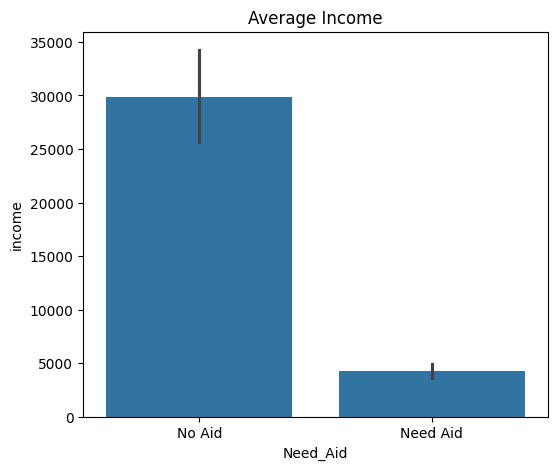

In [20]:
#Average Income by Need_Aid

plt.figure(figsize=(6,5))

sns.barplot(data=df,x="Need_Aid",y="income")

plt.xticks([0,1],["No Aid","Need Aid"])

plt.title("Average Income")

plt.show()

Countries labeled as needing aid have significantly lower average income.

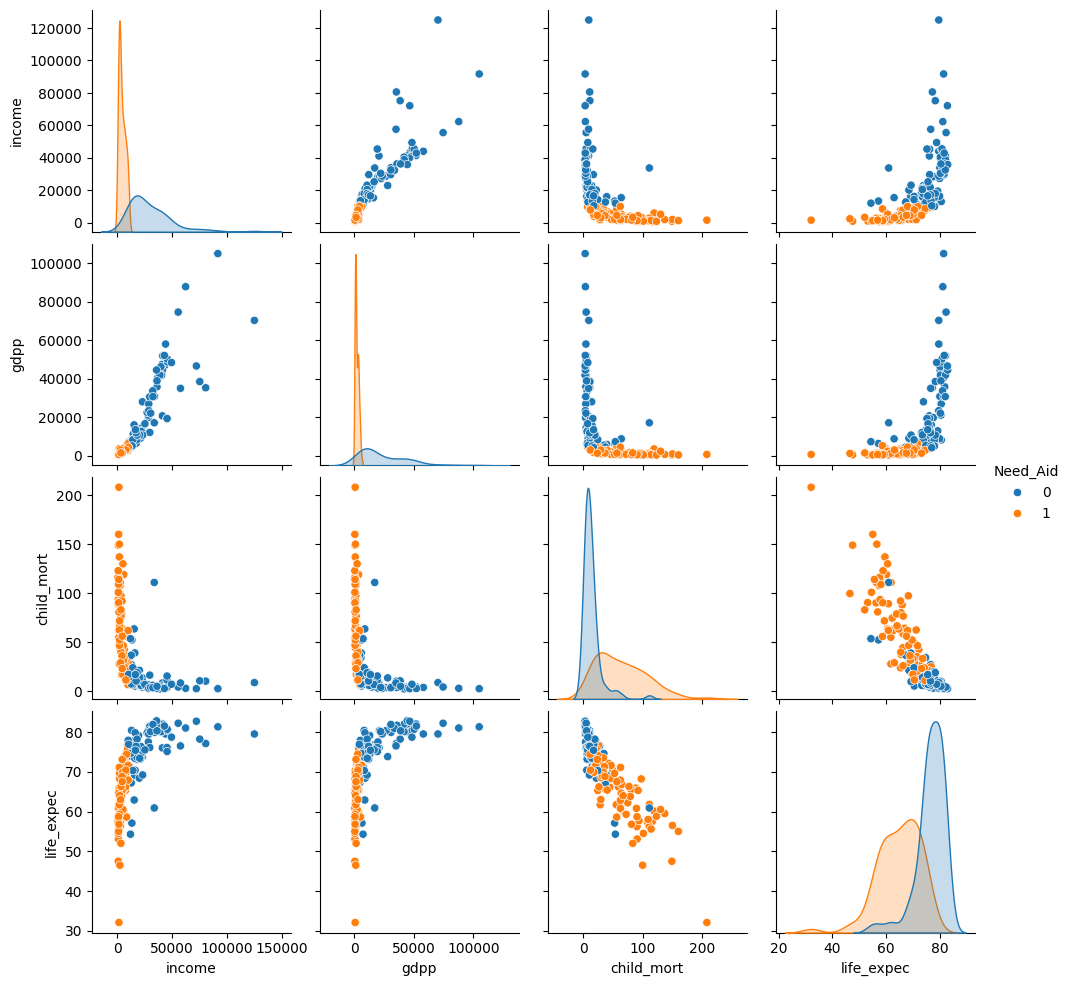

In [21]:
#Pairplot

sns.pairplot(df,vars=["income","gdpp","child_mort","life_expec"],hue="Need_Aid")

plt.show()

The pairplot clearly shows that countries with lower income and GDP generally have higher child mortality and lower life expectancy.

## EDA Summary

- The dataset contains no missing values.
- Income and GDP are strongly positively correlated.
- Child mortality decreases as income increases.
- Life expectancy increases with higher income.
- Some countries have unusually high inflation values.
- Countries requiring aid generally have low income and GDP with higher child mortality.

In [22]:
#Random Forest Classification

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [23]:
#Random Forest Evaluation

print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_pred))

print("\nClassification Report\n")

print(classification_report(y_test,rf_pred))

Random Forest Accuracy: 1.0

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        17
           1       1.00      1.00      1.00        17

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



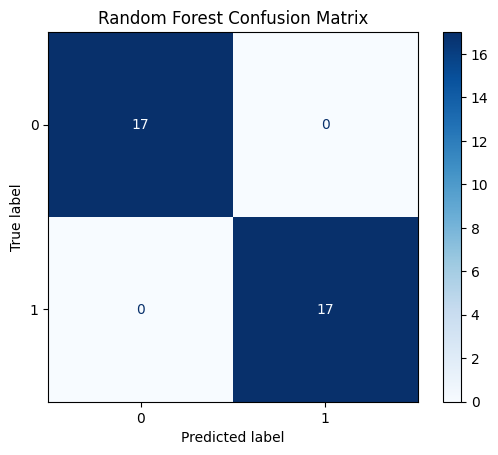

In [24]:
#Confusion Matrix

cm = confusion_matrix(y_test,rf_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")

plt.title("Random Forest Confusion Matrix")

plt.show()

Random Forest achieved high classification accuracy and correctly classified most countries into the aid and non-aid categories.

In [26]:
#Feature Importance

importance = pd.DataFrame({"Feature":X.columns,"Importance":rf.feature_importances_})

importance = importance.sort_values(by="Importance",ascending=False)

importance

,Feature,Importance
4,income,0.432777
8,gdpp,0.266689
0,child_mort,0.112647
7,total_fer,0.075252
6,life_expec,0.070028
1,exports,0.017288
2,health,0.011279
5,inflation,0.007388
3,imports,0.006652


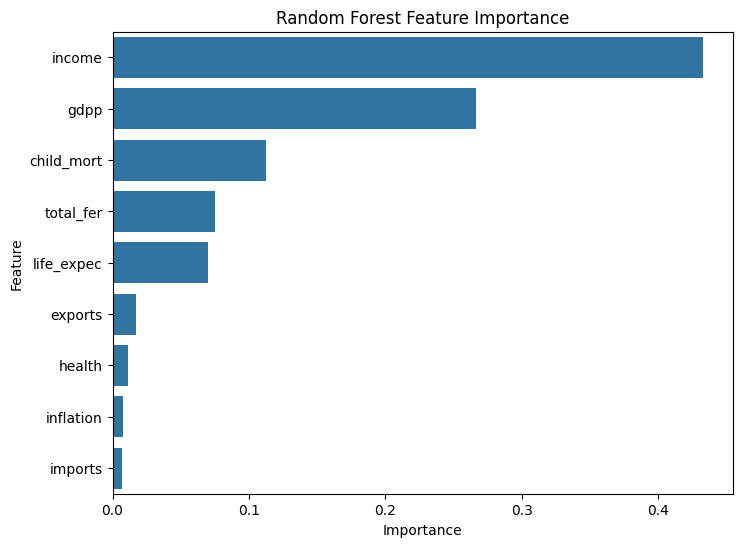

In [27]:
#Feature Importance Plot

plt.figure(figsize=(8,6))

sns.barplot(data=importance,x="Importance",y="Feature")

plt.title("Random Forest Feature Importance")

plt.show()

Income, GDP, child mortality and life expectancy contribute the most towards predicting whether a country needs aid.

In [28]:
#XGBoost Classification

from xgboost import XGBClassifier

xgb = XGBClassifier(random_state=42,eval_metric="logloss")



In [29]:
xgb.fit(X_train,y_train)



XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [30]:
xgb_pred = xgb.predict(X_test)

In [31]:
#XGBoost Evaluation

print("XGBoost Accuracy:",accuracy_score(y_test,xgb_pred))

print("\nClassification Report\n")

print(classification_report(y_test,xgb_pred))

XGBoost Accuracy: 1.0

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        17
           1       1.00      1.00      1.00        17

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



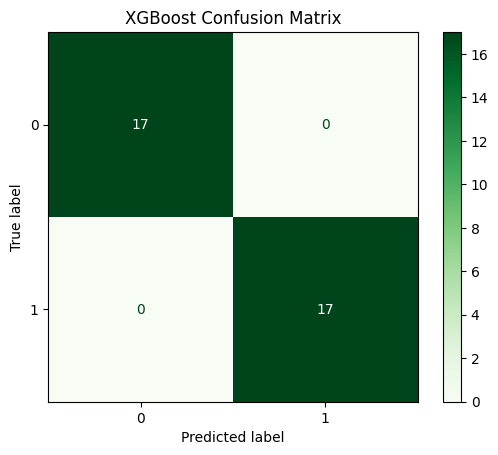

In [33]:
#XGBoost Confusion Matrix

cm = confusion_matrix(y_test,xgb_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Greens")

plt.title("XGBoost Confusion Matrix")

plt.show()

In [34]:
#Hyperparameter Tuning

param_grid = {"n_estimators":[50,100,150],"max_depth":[3,5,7],"min_samples_split":[2,5,10]}

In [35]:
grid = GridSearchCV(RandomForestClassifier(random_state=42),param_grid,cv=5,scoring="accuracy")

grid.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
             param_grid={'max_depth': [3, 5, 7],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 150]},
             scoring='accuracy')

In [36]:
#Best Parameters

print("Best Parameters:")

print(grid.best_params_)

print("\nBest Accuracy:")

print(grid.best_score_)

Best Parameters:
{'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 150}

Best Accuracy:
0.9923076923076923


In [37]:
#Best Model

best_rf = grid.best_estimator_

best_pred = best_rf.predict(X_test)

print(classification_report(y_test,best_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        17
           1       1.00      1.00      1.00        17

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



In [38]:
#Model Comparison

comparison = pd.DataFrame({"Model":["Random Forest","XGBoost"],"Accuracy":[accuracy_score(y_test,rf_pred),
accuracy_score(y_test,xgb_pred)]})

comparison

,Model,Accuracy
0,Random Forest,1.0
1,XGBoost,1.0


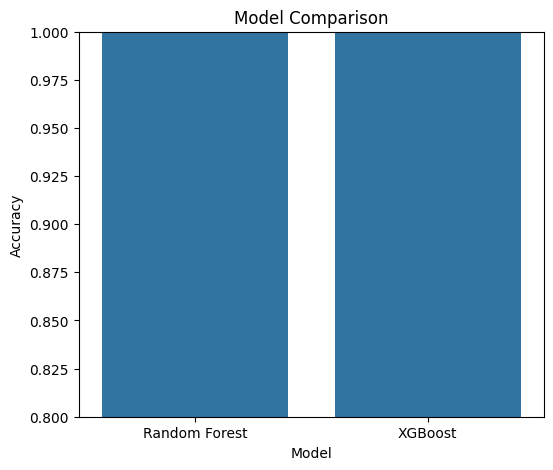

In [39]:
#Accuracy Comparison

plt.figure(figsize=(6,5))

sns.barplot(data=comparison,x="Model",y="Accuracy")

plt.ylim(0.8,1)

plt.title("Model Comparison")

plt.show()

Both Random Forest and XGBoost achieved high accuracy. The better-performing model can be selected based on the highest accuracy and overall classification metrics.

In [40]:
#K-Means Clustering

from sklearn.cluster import KMeans

wcss = []

for i in range(1,11):

    kmeans = KMeans(n_clusters=i,random_state=42,n_init=10)

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

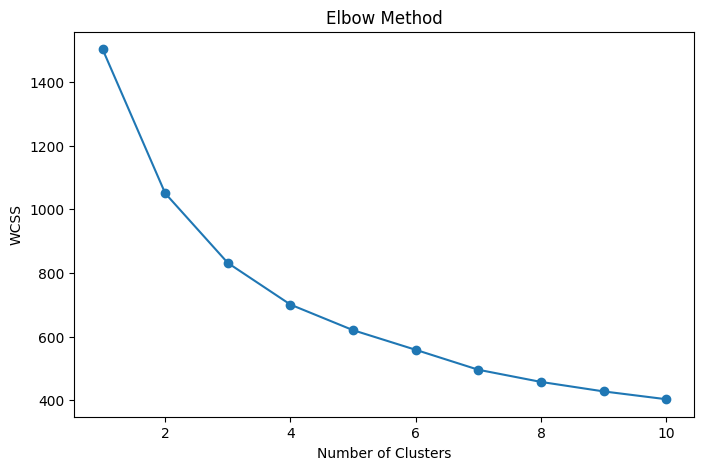

In [41]:
#Elbow Method

plt.figure(figsize=(8,5))

plt.plot(range(1,11),wcss,marker='o')

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()

The elbow curve shows a sharp decrease until around 3 clusters. Therefore, K=3 is selected as the optimal number of clusters.

In [42]:
#KMeans Model

kmeans = KMeans(n_clusters=3,random_state=42,n_init=10)

df["Cluster"] = kmeans.fit_predict(X_scaled)

df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Need_Aid,Cluster
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,1,1
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,1,2
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,0,2
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,1,1
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,0,2


In [43]:
#Silhouette Score

score = silhouette_score(X_scaled,df["Cluster"])

print("Silhouette Score:",score)

Silhouette Score: 0.28329575683463126


The silhouette score measures how well the countries are grouped into clusters. A higher score indicates better cluster separation.

In [44]:
#PCA

from sklearn.decomposition import PCA

pca = PCA(n_components=2)

principal_components = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(principal_components,columns=["PC1","PC2"])

pca_df["Cluster"] = df["Cluster"]

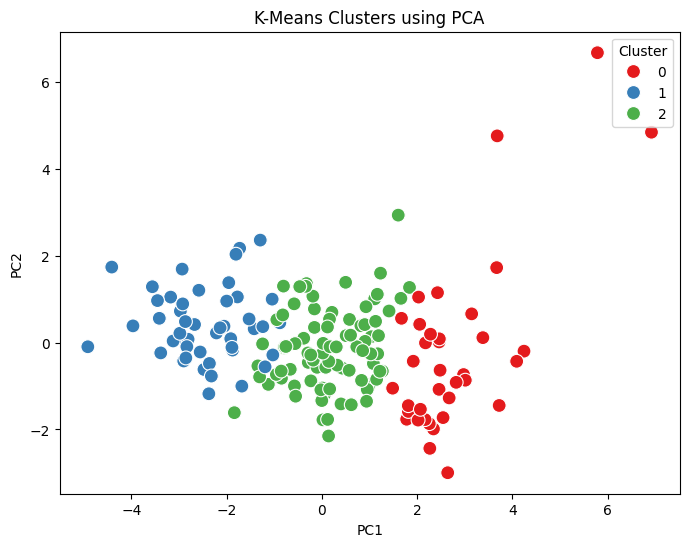

In [45]:
#KMeans Cluster Plot

plt.figure(figsize=(8,6))

sns.scatterplot(data=pca_df,x="PC1",y="PC2",hue="Cluster",palette="Set1",s=100)

plt.title("K-Means Clusters using PCA")

plt.show()

PCA reduces the data into two dimensions, making it easier to visualize the three country clusters.

In [46]:
#DBSCAN

from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=1.5,min_samples=5)

df["DBSCAN_Cluster"] = dbscan.fit_predict(X_scaled)

df["DBSCAN_Cluster"].value_counts()

,count
DBSCAN_Cluster,
0,137
-1,30


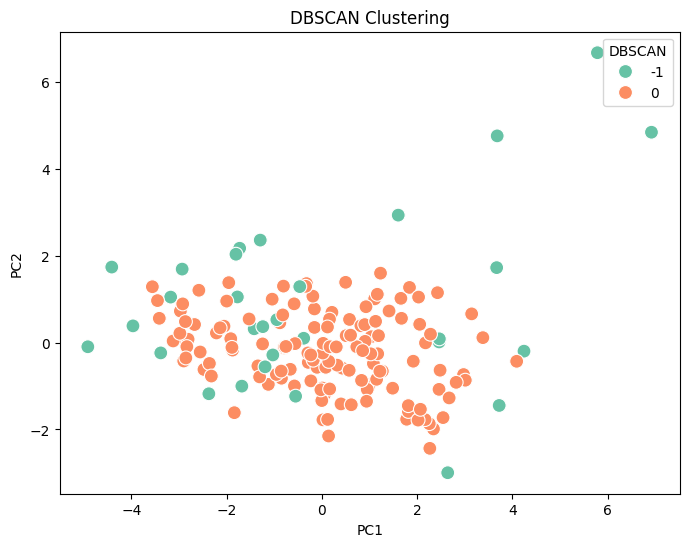

In [47]:
#DBSCAN Visualization

pca_df["DBSCAN"] = df["DBSCAN_Cluster"]

plt.figure(figsize=(8,6))

sns.scatterplot(data=pca_df,x="PC1",y="PC2",hue="DBSCAN",palette="Set2",s=100)

plt.title("DBSCAN Clustering")

plt.show()

DBSCAN groups countries based on density and is able to identify outliers that do not belong to any cluster.

In [48]:
#Cluster Statistics

cluster_summary = df.groupby("Cluster")[["income","gdpp","child_mort","life_expec"]].mean()

cluster_summary

,income,gdpp,child_mort,life_expec
Cluster,,,,
0,45672.222222,42494.444444,5.000000,80.127778
1,3942.404255,1922.382979,92.961702,59.187234
2,12305.595238,6486.452381,21.927381,72.814286


In [50]:
# Countries Needing Aid

aid_countries = df[df["Cluster"] == 1].sort_values(by="income")

aid_countries[["country","income","gdpp","child_mort","life_expec"]].head(20)

,country,income,gdpp,child_mort,life_expec
37,"Congo, Dem. Rep.",609,334,116.0,57.5
88,Liberia,700,327,89.3,60.8
26,Burundi,764,231,93.6,57.7
112,Niger,814,348,123.0,58.8
31,Central African Republic,888,446,149.0,47.5
106,Mozambique,918,419,101.0,54.5
94,Malawi,1030,459,90.5,53.1
63,Guinea,1190,648,109.0,58.0
150,Togo,1210,488,90.3,58.7
132,Sierra Leone,1220,399,160.0,55.0


### Cluster Analysis

The K-Means algorithm divided the countries into three clusters.

- **Cluster 0** contains developed countries with the highest income, highest GDP, lowest child mortality, and highest life expectancy.
- **Cluster 2** contains developing countries with moderate economic and health conditions.
- **Cluster 1** contains the least developed countries with the lowest income and GDP, the highest child mortality, and the lowest life expectancy. Therefore, these countries should be given the highest priority for financial aid by HELP International.

The clustering results clearly show that Cluster 1 represents the countries facing the greatest socio-economic challenges. These countries have poor economic conditions and health indicators, making them the most suitable candidates for receiving financial assistance from HELP International.

In this project, I developed a Customer Intelligence System using classification, ensemble learning, and clustering techniques. Random Forest and XGBoost were used to classify countries, while K-Means and DBSCAN grouped countries with similar socio-economic characteristics. The clustering analysis identified three groups of countries, where Cluster 1 represents the countries most in need of aid due to their low income, low GDP, high child mortality, and low life expectancy. This project demonstrates how machine learning can help organizations like HELP International make better and more informed decisions about resource allocation.